In [ ]:
!sudo apt update
!apt-get install openjdk-8-jdk-headless -qq > /dev/null
#Check this site for the latest download link https://www.apache.org/dyn/closer.lua/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!wget -q https://dlcdn.apache.org/spark/spark-3.2.1/spark-3.2.1-bin-hadoop3.2.tgz
!tar xf spark-3.2.1-bin-hadoop3.2.tgz
!pip install -q findspark
!pip install pyspark
!pip install py4j

import os
import sys
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-8-openjdk-amd64"
# os.environ["SPARK_HOME"] = "/content/spark-3.2.1-bin-hadoop3.2"


import findspark
findspark.init()
findspark.find()

import pyspark

from pyspark.sql import DataFrame, SparkSession
from typing import List
import pyspark.sql.types as T
import pyspark.sql.functions as F
from pyspark.sql import SparkSession
from pyspark.sql.functions import col,count
import requests

spark= SparkSession \
       .builder \
       .appName("Datos desde un CSV") \
       .getOrCreate()

spark

Hit:1 https://cli.github.com/packages stable InRelease
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,077 kB]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Hit:12 https://ppa.launchpadcontent.net/ubuntugis/ppa/ubuntu jammy InRelease
Get:13 https://r2u.stat.illinois.edu/ubuntu jammy/main all Pack

In [ ]:
import requests
import pandas as pd
from google.colab import data_table  # Para usar DataTable en Colab
import matplotlib.pyplot as plt


# Descargar el archivo CSV desde la URL
path = "https://raw.githubusercontent.com/Data-Market/productos-de-supermercados/refs/heads/main/productos-de-supermercado-sample.csv"
req = requests.get(path)
url_content = req.content
name_file = "productos-de-supermercado-sample.csv"
csv_file = open(name_file, "wb")
csv_file.write(url_content)

# Cargar el archivo CSV en PySpark
df = spark.read.csv('/content/' + name_file, header=True, inferSchema=True)

# Convertir el DataFrame de PySpark a Pandas para visualizarlo de forma más amigable
df_pandas = df.toPandas()

# Usar DataTable para mostrar el DataFrame como si fuera una tabla de Excel
data_table.DataTable(df_pandas, include_index=False, num_rows_per_page=10)

,supermarket,category,name,description,price,reference_price,reference_unit,insert_date
0,mercadona-es,postres_y_yogures_yogures_liquidos,Bebida láctea sin lactosa de fresa Hacendado,Pack-4,1.4,2.19,kg,2020-12-23 00:00:00
1,mercadona-es,bodega_licores,Ginebra 15 botanicals Blumara,Botella,10.75,15.36,L,2020-11-06 12:00:00
2,mercadona-es,charcuteria_y_quesos_queso_untable_y_fresco,Queso fresco batido desnatado Hacendado 0% mat...,Tarrina,1.09,2.18,kg,2020-09-23 16:06:00
3,carrefour-es,la_despensa_yogures_y_postres_yogures_desnatados,Yogur bífidus desnatado con lima y limón Danon...,Pack 4x120 G.,2.08,4.33,kg,2020-10-10 00:00:00
4,carrefour-es,la_despensa_helados_bombon,Helado After Dinner Magnum sin gluten 10 ud.,10 Ud.,4.6,0.46,ud,2020-10-15 00:00:00
...,...,...,...,...,...,...,...,...
150002,mercadona-es,bodega_cerveza,Cerveza Clásica Steinburg,Botella,0.7,0.7,L,2020-12-11 00:00:00
150003,mercadona-es,mascotas_gato,Gelatina gato Felix selección de sabores,Paquete,1.49,3.73,kg,2020-12-16 04:00:00
150004,carrefour-es,mascotas_gatos_pienso_para_gatos,Ultima Pienso para Gato Esterilizado Sabor pol...,3 Kg.,14.25,4.75,kg,2020-10-31 00:00:00
150005,dia-es,bebidas_refrescos_naranja,DIA refresco de naranja zero botella 2 lt,None,0.79,0.4,€/l.,2020-08-01 16:00:00


#Analisis Exploratorio

In [ ]:
df.printSchema() # Se nota que el precio esta en formato String cuando deberia de ser Numerico

root
 |-- supermarket: string (nullable = true)
 |-- category: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- price: string (nullable = true)
 |-- reference_price: string (nullable = true)
 |-- reference_unit: string (nullable = true)
 |-- insert_date: timestamp (nullable = true)



In [ ]:
df.select("supermarket").distinct().show()

+--------------------+
|         supermarket|
+--------------------+
|Licor del Polo 50...|
|        carrefour-es|
|                 g."|
|              dia-es|
|        mercadona-es|
+--------------------+



In [ ]:
df.groupBy("supermarket").agg(count("supermarket")).show()

+--------------------+------------------+
|         supermarket|count(supermarket)|
+--------------------+------------------+
|Licor del Polo 50...|                 3|
|        carrefour-es|             88444|
|                 g."|                 4|
|              dia-es|             31674|
|        mercadona-es|             29882|
+--------------------+------------------+



In [ ]:
df.where(~(F.col("supermarket").isin("carrefour-es","dia-es","mercadona-es"))).count()

7

In [ ]:
df.where(~(F.col("supermarket").isin("carrefour-es","dia-es","mercadona-es"))).show(truncate=False)

+-----------------------+--------+----+-----------+-----+-------------------+--------------+-----------+
|supermarket            |category|name|description|price|reference_price    |reference_unit|insert_date|
+-----------------------+--------+----+-----------+-----+-------------------+--------------+-----------+
| g."                   |NULL    |1.99|4.15       |kg   |2021-01-06 00:00:00|NULL          |NULL       |
|Licor del Polo 500 ml."|NULL    |4.35|0.87       |100ml|2021-01-07 00:00:00|NULL          |NULL       |
| g."                   |NULL    |1.99|4.15       |kg   |2020-12-24 00:00:00|NULL          |NULL       |
|Licor del Polo 500 ml."|NULL    |4.35|0.87       |100ml|2021-01-16 00:00:00|NULL          |NULL       |
| g."                   |NULL    |1.95|4.06       |kg   |2021-01-27 12:00:00|NULL          |NULL       |
| g."                   |NULL    |1.95|4.06       |kg   |2021-01-28 00:00:00|NULL          |NULL       |
|Licor del Polo 500 ml."|NULL    |4.35|0.87       |100m

# ETL Simulada al DataLake

In [ ]:
df.coalesce(1).where((F.col("supermarket").isin("carrefour-es","dia-es","mercadona-es")))\
      .withColumn("Fecha_Registro", F.col("insert_date").cast("date"))\
      .write.partitionBy("supermarket","Fecha_Registro").mode("overwrite").parquet("Datos_Distribuidos")

In [ ]:
#nombre_reparticion = "part-01.parquet"
# part-00000-c035ed5f-a675-4aee-b5b5-f8f358a902da.c000.snappy.parquet
# part-00000-04832a8f-2e02-4e88-9d7c-426212e8df5a.c000.snappy.parquet
#spark.read.parquet('/content/Datos_Limpios/' + nombre_reparticion).count()

89539

In [ ]:
#nombre_reparticion = "part-02.parquet"
#spark.read.parquet('/content/Datos_Limpios/' + nombre_reparticion).count()

60461

In [ ]:
spark.read.parquet('/content/Datos_Distribuidos').count()

150000

In [ ]:
spark.read.parquet('/content/Datos_Distribuidos').where(F.col("supermarket")=="mercadona-es").count()


29882

In [ ]:
spark.read.parquet('/content/Datos_Distribuidos').where(F.col("supermarket")=="mercadona-es").printSchema()


root
 |-- category: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- price: string (nullable = true)
 |-- reference_price: string (nullable = true)
 |-- reference_unit: string (nullable = true)
 |-- insert_date: timestamp (nullable = true)
 |-- supermarket: string (nullable = true)
 |-- Fecha_Registro: date (nullable = true)



In [ ]:
# Lectura por partición
spark.read.parquet('/content/Datos_Distribuidos/supermarket=mercadona-es').count()

29882

In [ ]:
# Esquema por lectura desde partición
spark.read.parquet('/content/Datos_Distribuidos/supermarket=mercadona-es').printSchema()

root
 |-- category: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- price: string (nullable = true)
 |-- reference_price: string (nullable = true)
 |-- reference_unit: string (nullable = true)
 |-- insert_date: timestamp (nullable = true)
 |-- Fecha_Registro: date (nullable = true)



In [ ]:
# Esquema por lectura desde partición pero con el path completo
spark.read.option("basePath","/content/Datos_Distribuidos")\
                    .parquet("/content/Datos_Distribuidos/supermarket=mercadona-es").printSchema()

root
 |-- category: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- price: string (nullable = true)
 |-- reference_price: string (nullable = true)
 |-- reference_unit: string (nullable = true)
 |-- insert_date: timestamp (nullable = true)
 |-- supermarket: string (nullable = true)
 |-- Fecha_Registro: date (nullable = true)



In [ ]:
# Esquema por lectura desde partición pero agregando la sub carpeta faltante de la partición
#spark.read.parquet('/content/Datos_Limpios/supermarket=mercadona-es').count()
#spark.read.parquet('/content/Datos_Limpios/supermarket=mercadona-es').withColumn("supermarket",F.lit("mercadona-es")).printSchema()


# Revisión de productos entre supermercados

In [ ]:
# Esquema por lectura desde partición pero con el path completo
df_mercadona = spark.read.option("basePath","/content/Datos_Distribuidos")\
                    .parquet("/content/Datos_Distribuidos/supermarket=mercadona-es")
df_dia = spark.read.option("basePath","/content/Datos_Distribuidos")\
                    .parquet("/content/Datos_Distribuidos/supermarket=dia-es")
df_carrefour = spark.read.option("basePath","/content/Datos_Distribuidos")\
                    .parquet("/content/Datos_Distribuidos/supermarket=carrefour-es")


In [ ]:
df_mercadona.printSchema()

root
 |-- category: string (nullable = true)
 |-- name: string (nullable = true)
 |-- description: string (nullable = true)
 |-- price: string (nullable = true)
 |-- reference_price: string (nullable = true)
 |-- reference_unit: string (nullable = true)
 |-- insert_date: timestamp (nullable = true)
 |-- supermarket: string (nullable = true)
 |-- Fecha_Registro: date (nullable = true)



In [ ]:
print("Total de Categorias en Mercadona: ", df_mercadona.select("category").distinct().count())
print("Total de Categorias en Dia: ", df_dia.select("category").distinct().count())
print("Total de Categorias en Carrefour: ", df_carrefour.select("category").distinct().count())


Total de Categorias en Mercadona:  155
Total de Categorias en Dia:  593
Total de Categorias en Carrefour:  543


In [ ]:
df_mercadona.select("category").distinct().orderBy(F.col("category").asc()).show(truncate=False)

+---------------------------------------------------+
|category                                           |
+---------------------------------------------------+
|aceite_especias_y_salsas_aceite_vinagre_y_sal      |
|aceite_especias_y_salsas_especias                  |
|aceite_especias_y_salsas_mayonesa_ketchup_y_mostaza|
|aceite_especias_y_salsas_otras_salsas              |
|agua_y_refrescos_agua                              |
|agua_y_refrescos_isotonico_y_energetico            |
|agua_y_refrescos_refresco_de_cola                  |
|agua_y_refrescos_refresco_de_naranja_y_de_limon    |
|agua_y_refrescos_refresco_de_te_y_sin_gas          |
|agua_y_refrescos_tonica_y_bitter                   |
|aperitivos_aceitunas_y_encurtidos                  |
|aperitivos_frutos_secos_y_fruta_desecada           |
|aperitivos_patatas_fritas_y_snacks                 |
|arroz_legumbres_y_pasta_arroz                      |
|arroz_legumbres_y_pasta_legumbres                  |
|arroz_legumbres_y_pasta_pas

In [ ]:
df_dia.select("category").distinct().orderBy(F.col("category").asc()).show(truncate=False)

+---------------------------------------------------------------+
|category                                                       |
+---------------------------------------------------------------+
|alimentacion_aceite_aceite_de_girasol                          |
|alimentacion_aceite_aceite_de_oliva_intenso_06o1o              |
|alimentacion_aceite_aceite_de_oliva_suave_05o                  |
|alimentacion_aceite_aceite_de_oliva_virgen_y_virgen_extra      |
|alimentacion_aceite_otros_aceites                              |
|alimentacion_aceitunas_y_encurtidos_aceitunas_negras           |
|alimentacion_aceitunas_y_encurtidos_aceitunas_rellenas         |
|alimentacion_aceitunas_y_encurtidos_aceitunas_verdes           |
|alimentacion_aceitunas_y_encurtidos_encurtidos                 |
|alimentacion_arroz_cocido                                      |
|alimentacion_arroz_especial_integral_y_semolas                 |
|alimentacion_arroz_largo                                       |
|alimentac

In [ ]:
df_carrefour.select("category").distinct().orderBy(F.col("category").asc()).show(truncate=False)

+---------------------------------------------------------------------------+
|category                                                                   |
+---------------------------------------------------------------------------+
|bebe_alimentacion_infantil_agua_embotellada                                |
|bebe_alimentacion_infantil_bio_en_alimentacion_infantil                    |
|bebe_alimentacion_infantil_complementos_alimenticios_e_infusiones_para_bebe|
|bebe_alimentacion_infantil_leches_infantiles                               |
|bebe_alimentacion_infantil_papillas_y_galletas                             |
|bebe_alimentacion_infantil_postres_zumos_petit_y_yogures_infantiles        |
|bebe_alimentacion_infantil_tarritos_y_platos_preparados                    |
|bebe_bio_en_bebe                                                           |
|bebe_embarazo_y_lactancia_compresas_y_protegeslips                         |
|bebe_embarazo_y_lactancia_cremas_y_aceites                     

In [ ]:
df_mercadona.join(df_dia, "category", "inner")\
              .join(df_carrefour, "category", "inner")\
              .show()

+--------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+
|category|name|description|price|reference_price|reference_unit|insert_date|supermarket|Fecha_Registro|name|description|price|reference_price|reference_unit|insert_date|supermarket|Fecha_Registro|name|description|price|reference_price|reference_unit|insert_date|supermarket|Fecha_Registro|
+--------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+
+--------+----+-----------+-----+---------------+--------------+-----------+-----------+--------------+----+-----------+-----+----

In [ ]:
pd_mercadona_promedio = df_mercadona.groupBy("category").agg(F.avg("price").alias("Precio_Promedio"))\
                            .orderBy(F.col("Precio_Promedio").desc())\
                            .toPandas().head(5)
pd_dia_promedio = df_dia.groupBy("category").agg(F.avg("price").alias("Precio_Promedio"))\
                            .orderBy(F.col("Precio_Promedio").desc())\
                            .toPandas().head(5)
pd_carrefour_promedio = df_carrefour.groupBy("category").agg(F.avg("price").alias("Precio_Promedio"))\
                            .orderBy(F.col("Precio_Promedio").desc())\
                            .toPandas().head(5)

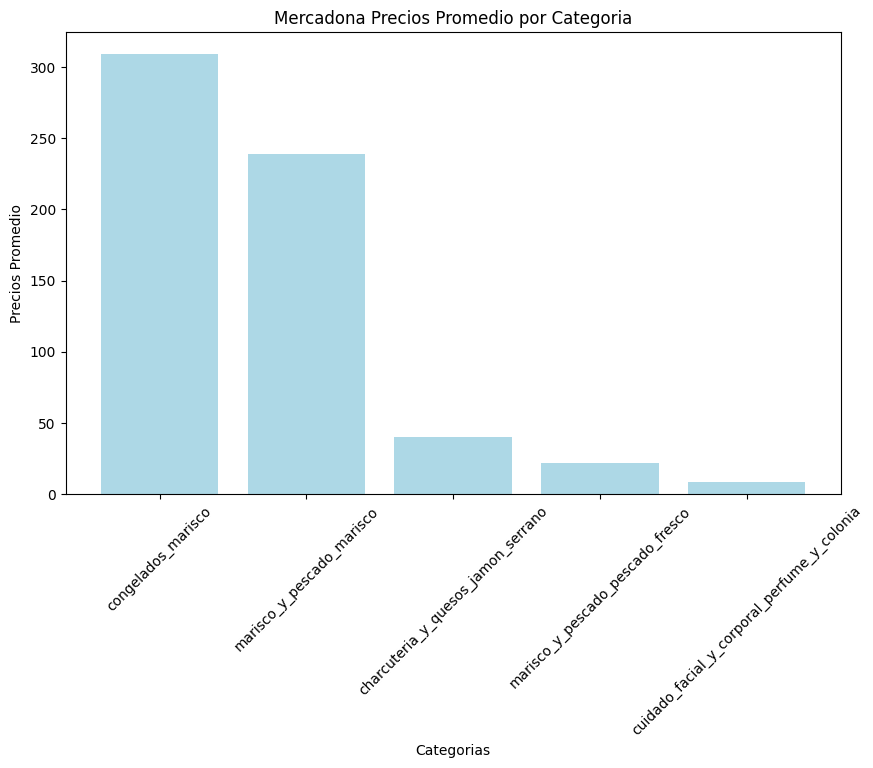

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.bar(pd_mercadona_promedio["category"], pd_mercadona_promedio["Precio_Promedio"], color = "lightblue")
plt.title("Mercadona Precios Promedio por Categoria")
plt.xlabel("Categorias")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)
plt.show()

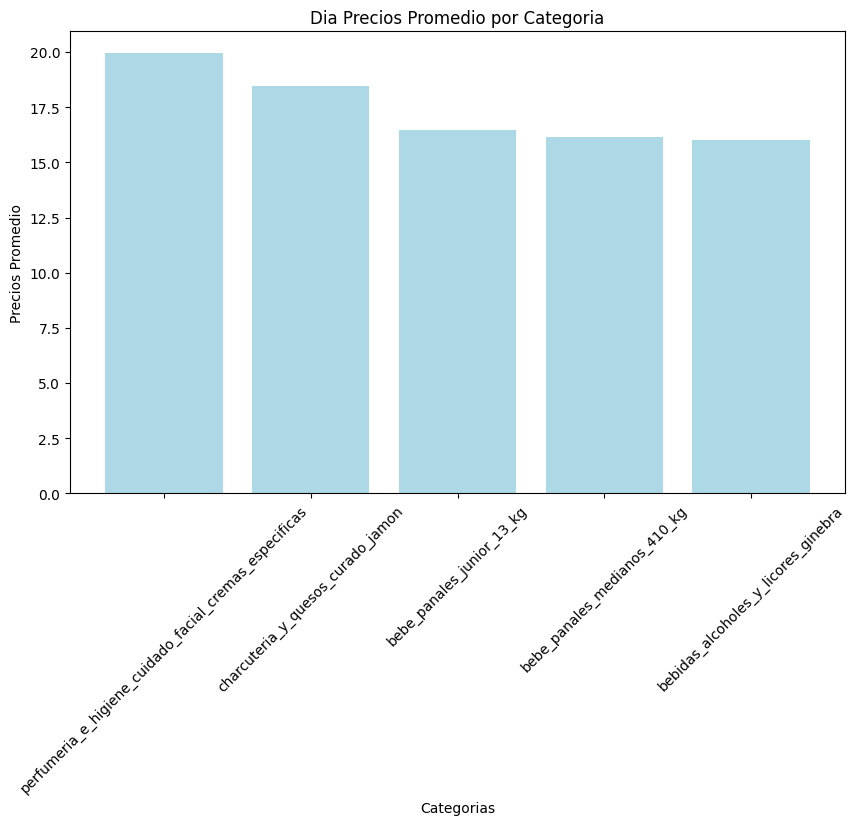

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.bar(pd_dia_promedio["category"], pd_dia_promedio["Precio_Promedio"], color = "lightblue")
plt.title("Dia Precios Promedio por Categoria")
plt.xlabel("Categorias")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)
plt.show()

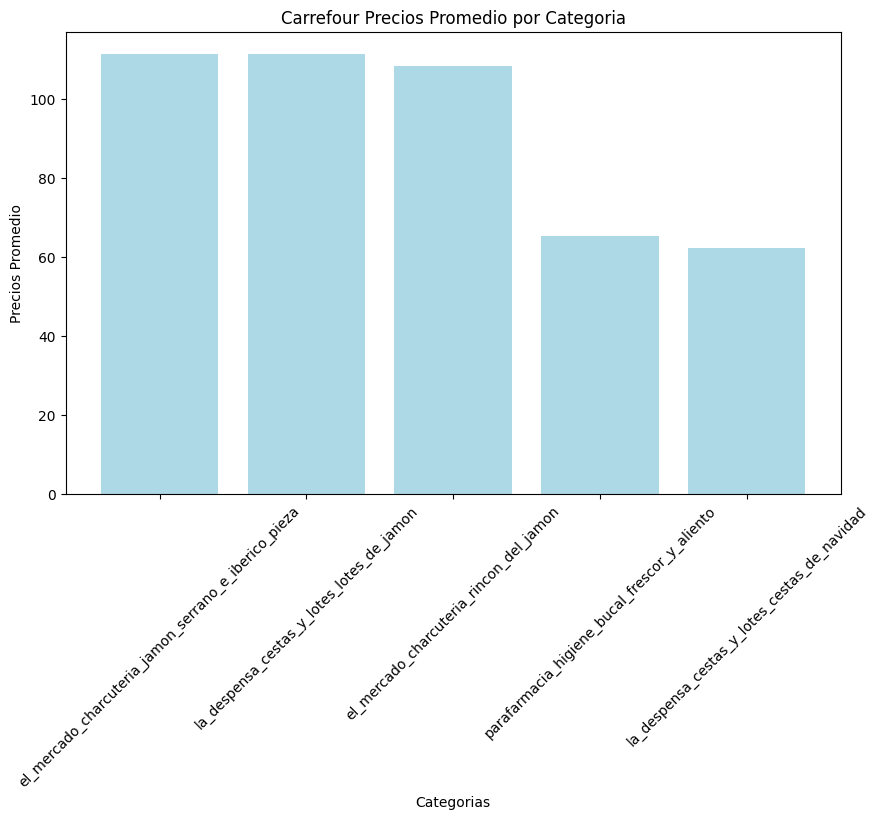

In [ ]:
import matplotlib.pyplot as plt
plt.figure(figsize = (10,6))
plt.bar(pd_carrefour_promedio["category"], pd_carrefour_promedio["Precio_Promedio"], color = "lightblue")
plt.title("Carrefour Precios Promedio por Categoria")
plt.xlabel("Categorias")
plt.ylabel("Precios Promedio")
plt.xticks(rotation=45)
plt.show()